# Variational Autoencoder (VAE)

_[based on our assignment from YSDA [DeepCVG course](https://github.com/yandexdataschool/deep_vision_and_graphics/tree/fall23); materials by Victor Yurchenko]_

**TL;DR this task** will walk involve you implementing your variational autoencoder with normal latent variables - just the basic variety - to model celebrity faces from CelebA dataset.

![img](https://miro.medium.com/v2/resize:fit:1400/0*39kjKwCtVjhrvsQ7.png)


Source links (in addition to our materials):
* Original paper http://arxiv.org/abs/1312.6114
* Helpful videos explaining the topic
   * https://www.youtube.com/watch?v=P78QYjWh5sM     
   * http://videolectures.net/deeplearning2015_courville_autoencoder_extension/?q=aaron%20courville
  

### Download data

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: celeba/celeba/img_align_celeba/138950.jpg  
  inflating: celeba/celeba/img_align_celeba/117264.jpg  
  inflating: celeba/celeba/img_align_celeba/112606.jpg  
  inflating: celeba/celeba/img_align_celeba/053676.jpg  
  inflating: celeba/celeba/img_align_celeba/158869.jpg  
  inflating: celeba/celeba/img_align_celeba/170252.jpg  
  inflating: celeba/celeba/img_align_celeba/021665.jpg  
  inflating: celeba/celeba/img_align_celeba/174525.jpg  
  inflating: celeba/celeba/img_align_celeba/042747.jpg  
  inflating: celeba/celeba/img_align_celeba/165952.jpg  
  inflating: celeba/celeba/img_align_celeba/148026.jpg  
  inflating: celeba/celeba/img_align_celeba/015537.jpg  
  inflating: celeba/celeba/img_align_celeba/107859.jpg  
  inflating: celeba/celeba/img_align_celeba/127972.jpg  
  inflating: celeba/celeba/img_align_celeba/056173.jpg  
  inflating: celeba/celeba/img_align_celeba/065547.jpg  
  inflating: celeba/

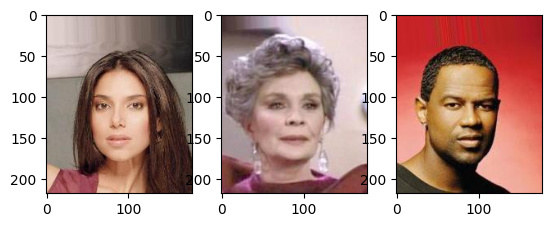

In [3]:
!wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall24/week09_generative/yfile.py -O yfile.py
from yfile import download_from_yadisk
import os

TARGET_DIR = '.'
FILENAME = "celeba.zip"

if not os.path.exists(os.path.join(TARGET_DIR, FILENAME)):
  print("Downloading...") # this will download 1.4 gb file, downloading will take some time (8-10 minutes)
  download_from_yadisk(short_url='https://disk.yandex.ru/d/QErNx-MoC-2Y6Q',
                        filename=FILENAME, target_dir=TARGET_DIR)
  # alternative manual download:  https://drive.google.com/file/d/1lwn2JMwWNGloGvyzKUOcewT8JqP1ICoW

  print("Extracting...")
  !unzip celeba.zip  # extract images; you don't need to run it every time
  print("Done!")
else:
  print("Found previously downloaded data!")

filesize = os.path.getsize(os.path.join(TARGET_DIR, FILENAME))
assert filesize > 2 ** 30, "{filesize} GiB is too small, something wrong with downloading - please clean up and re-download"

import matplotlib.pyplot as plt
plt.subplot(131); plt.imshow(plt.imread("celeba/celeba/img_align_celeba/100019.jpg"))
plt.subplot(132); plt.imshow(plt.imread("celeba/celeba/img_align_celeba/000084.jpg"))
plt.subplot(133); plt.imshow(plt.imread("celeba/celeba/img_align_celeba/148483.jpg"))

## Prepare the data

In [4]:
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

In [6]:
# Note that for simplicity we reduce the number of channels to 1
# But if you want to be hardcore feel free to comment .Grayscale :)


class CropCelebA64:

    def __call__(self, pic):
        new_pic = pic.crop((15, 40, 178 - 15, 218 - 30))
        return new_pic

    def __repr__(self):
        return self.__class__.__name__ + '()'

train_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='train',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),

        torchvision.transforms.Grayscale()
    ]),
    #download=True,   # in case of problems with downloading from gdrive above
)

validation_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='valid',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.ToTensor(),

        torchvision.transforms.Grayscale()
    ]),
)


In [7]:
len(train_dataset)

162770

In [8]:
# Hold out the first 10k images for evaluation
num_images = 10000
real_images_tensor = torch.stack([train_dataset[i][0] for i in range(num_images)], dim=0)
real_images = real_images_tensor.data.numpy().transpose([0, 2, 3, 1])
np.savez("real.npz", Pictures=real_images.reshape(num_images, 64 * 64 * 1))

In [9]:
BATCH_SIZE = 128  # feel free to alter after initial tuning

# you may find useful parameters `num_workers` and `pin_memory`
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)
print("Image batch shape:", next(iter(train_loader))[0].shape)


Image batch shape: torch.Size([128, 1, 64, 64])


# Autoencoder

Why to use all this complicated formulaes and regularizations, what is the need for variational inference? To analyze the difference, let's first train just an autoencoder on the data:

In [10]:
def initialize_weight(model):
    for name, layer in model.named_parameters():
        if name.split('.')[-1]=="bias":
            nn.init.zeros_(layer.data)
        else:
            nn.init.xavier_uniform_(layer.data)


In [11]:
class Reshape(nn.Module):
    def __init__(self, shape):
        nn.Module.__init__(self)
        self.shape = shape

    def forward(self,input):
        return input.view(self.shape)

In [14]:
dimZ = 100  # Considering face reconstruction task, which size of representation seems reasonable?

# Define the decoder and encoder as networks with one hidden fc-layer
# (that means you will have 2 fc layers in each net)
# Use ReLU for hidden layers' activations
# GlorotUniform initialization for W
# Zero initialization for biases
# It's also convenient to put sigmoid activation on output layer to get nice normalized pics


class Autoencoder(nn.Module):

    def __init__(self):
        super(Autoencoder, self).__init__()

        # TODO

        self.encoder = nn.Sequential()

        self.encoder.add_module('flatten', nn.Flatten())

        self.encoder.add_module('linear1', nn.Linear(64**2, 512))
        self.encoder.add_module('act1', nn.ReLU())

        self.encoder.add_module('linear2', nn.Linear(512, dimZ))


        self.decoder = nn.Sequential()

        self.decoder.add_module('linear1', nn.Linear(dimZ, 512))
        self.decoder.add_module('act1', nn.ReLU())

        self.decoder.add_module('linear2', nn.Linear(512, 64**2))
        self.decoder.add_module('act2', nn.Sigmoid())
        self.decoder.add_module('reshape', Reshape([-1, 1, 64, 64]))

        # nn.init.xavier_uniform_(w, gain=nn.init.calculate_gain('relu'))

    def forward(self, x):

        # TODO

        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)

        return reconstruction, latent_code

In [15]:
# Create MSE loss function
criterion = torch.nn.MSELoss()

autoencoder = Autoencoder().to(device)
initialize_weight(autoencoder)

# Use Adam optimizer
optimizer = optim.Adam(autoencoder.parameters(),lr=1e-4)

In [16]:
# Train your autoencoder
# Visualize progress in reconstruction and loss decay

## Train and val part

In [17]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
%matplotlib inline
from tqdm import tqdm

In [18]:
def compute_loss(predictions, gt):
    return criterion(predictions,gt).mean()

In [19]:
def eval_model(model, dataloader):

    losses = []

    # num_correct = 0
    # num_elements = 0

    for i, batch in enumerate(dataloader):

        X_batch, y_batch = batch[0], batch[1]
        # num_elements += len(y_batch)

        with torch.no_grad():
            logits, _ = model(X_batch.to(device))

            loss = compute_loss(logits,X_batch.to(device))
            # loss_fn(logits, y_batch.to(device))
            losses.append(loss.item())

    #         y_pred = torch.argmax(logits, dim=1)

    #         num_correct += torch.sum(y_pred.cpu() == y_batch)

    # accuracy = num_correct / num_elements

    return  np.mean(losses)

In [20]:
def train_model(model, optimizer, train_data_generator):
    train_loss = []
    model.train(True) # enable dropout / batch_norm training behavior
    for i, batch in tqdm(enumerate(train_data_generator)):
        X_batch, y_batch = batch[0], batch[1]

        optimizer.zero_grad()

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        predictions, _ = model(X_batch)
        loss = compute_loss(predictions,X_batch)
        # print(loss.item())
        loss.backward()
        optimizer.step()

        train_loss.append(loss.cpu().data.numpy())
    return np.mean(train_loss)

In [21]:
def train_loop(model, optimizer, train_data_generator, val_data_generator, num_epochs, metrics):
    """
    num_epochs - total amount of full passes over training data
    """

    for epoch in range(num_epochs):
        # start_time = time.time()

        train_loss = train_model(model, optimizer, train_data_generator)

        val_loss = eval_model(model, val_data_generator)

        metrics['train_loss'].append((len(metrics['train_loss'])+1,train_loss))
        metrics['val_loss'].append((len(metrics['val_loss'])+1,val_loss))
        # metrics['val_accuracy'].append((len(metrics['val_accuracy'])+1,val_iou))

        clear_output(True)
        plt.figure(figsize=(12,4))

        plt.subplot(1, 1, 0 + 1)
        plt.title('Loss')
        plt.plot(*zip(*metrics['train_loss']),color='blue')
        plt.plot(*zip(*metrics['val_loss']),color='orange')
        plt.legend(['train','val'])
        plt.grid()

        # plt.subplot(1, 2, 1 + 1)
        # plt.title('accuracy')
        # plt.plot(*zip(*metrics['val_accuracy']))
        # plt.legend(['val'])
        # plt.grid()
        plt.show()


In [22]:
metrics = {'train_loss': [], 'val_loss': [],'val_accuracy':[]}

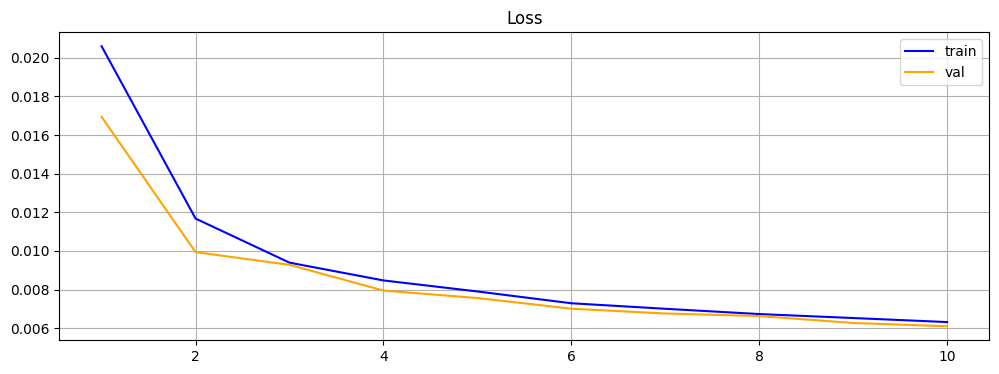

57it [00:20,  2.78it/s]


KeyboardInterrupt: 

In [24]:
train_loop(autoencoder, optimizer, train_loader, val_loader, 20, metrics)

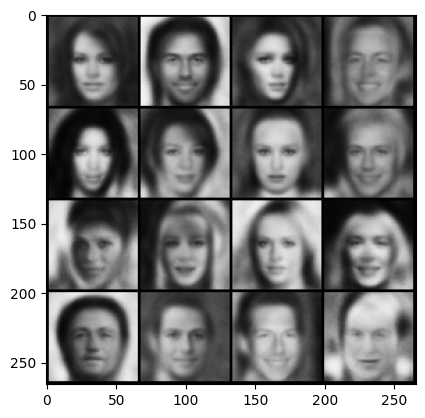

In [25]:
# Examine the reconstructions
from itertools import islice

images, _ = list(islice(val_loader, 1))[0]
reconstruction, latent_code = autoencoder(images.to(device))

reconstruction = reconstruction[:16].cpu()
plt.imshow(make_grid(reconstruction, nrow=4).permute(1, 2, 0))

Reconstruction is not bad, right?  Okay, it very well might be bad, but it should at least be a blurry image.

# Sampling

Let's now sample several latent vectors and perform inference from $z$, reconstruct an image given some random $z$ representations.

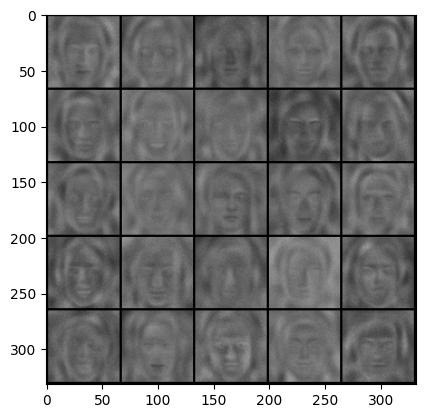

In [26]:
z = torch.randn(25, dimZ) * 0.5
reconstruction = autoencoder.decoder(z.to(device)).clamp(0, 1)

plt.imshow(make_grid(reconstruction.cpu(), nrow=5).permute(1, 2, 0))

So, if we sample $z$ from normal, whould we eventually generate all possible faces? What do you think?

# Variational Autoencoder

Bayesian approach in deep learning considers everything in terms of distributions. Now our encoder generates not just a vector $z$ but posterior ditribution $q(z|x)$. In our case distribution $q$ is Gaussian distibution $N(\mu, \sigma)$ with parameters $\mu$, $\sigma$. Technically, the first difference is that you need to split bottleneck layer in two. One dense layer will generate vector $\mu$, and another will generate vector $\sigma$. Reparametrization trick should be implemented using the **gaussian_sampler** layer, that generates random vetor $\epsilon$ and returns $\mu+\sigma\epsilon \sim N(\mu, \sigma)$ .

Since our decoder is also a function that generates distribution, we need to do the same splitting for output layer. When testing the model we will look only on mean values, so one of the output will be actual autoencoder output.

In this homework we only ask for implementation of the simplest version of VAE - one $z$ sample per input. You can consider to sample several outputs from one input and average them.

In [27]:
# to compare with conventional AE, keep these hyperparameters
# or change them for the values that you used before
dimZ = 100

# define the network
# you can start from https://github.com/pytorch/examples/blob/master/vae/main.py
# or Theano-based examples here https://github.com/Lasagne/Recipes/blob/master/examples/variational_autoencoder/variational_autoencoder.py
# and here https://github.com/y0ast/Variational-Autoencoder/blob/master/VAE.py
# but remember that this is not your ground truth since the data is not MNIST


class VAE(nn.Module):

    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(64**2, 512)
        self.fc21 = nn.Linear(512, dimZ)
        self.fc22 = nn.Linear(512, dimZ)
        self.fc3 = nn.Linear(dimZ, 512)
        self.fc41 = nn.Linear(512, 64**2)
        self.fc42 = nn.Linear(512, 64**2)


    def gaussian_sampler(self, mu, logsigma):
        noise = torch.randn_like(mu)
        return (noise * logsigma.exp() + mu).to(device)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc41(h3), self.fc42(h3)
        # return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        latent_mu, latent_logsigma = self.encode(x.view(-1, 64**2))
        z = self.gaussian_sampler(latent_mu, latent_logsigma)

        reconstract_mu, reconstruction_logsigma = self.decode(z)

        # return torch.sigmoid(reconstract_mu), reconstruction_logsigma, latent_mu, latent_logsigma
        return reconstract_mu, reconstruction_logsigma, latent_mu, latent_logsigma

        # return reconstruction_mu, reconstruction_logsigma, latent_mu, latent_logsigma

And the last, but not least! Place in the code where the most of the formulaes goes to - optimization objective. The objective for VAE has it's own name - variational lowerbound. And as for any lowerbound our intention is to maximize it. Here it is (for one sample $z$ per input $x$):

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z) \to max$$

Your next task is to implement two functions that compute KL-divergence and the second term - log-likelihood of an output. Here is some necessary math for your convenience:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$
$$\log p_{\theta}(x|z) = \sum_{i=1}^{dimX}\log p_{\theta}(x_i|z)=\sum_{i=1}^{dimX} \log \Big( \frac{1}{\sigma_i\sqrt{2\pi}}e^{-\frac{(\mu_i-x)^2}{2\sigma_i^2}} \Big)=...$$

Don't forget in the code that you are using $\log\sigma$ as variable. Explain, why not $\sigma$?

In [28]:
def KL_divergence(mu, logsigma):
    return -0.5 * torch.mean(1 + 2*logsigma - mu.pow(2) - logsigma.exp().pow(2),dim=1)


def log_likelihood(x, mu, logsigma):
    # print(logsigma.exp().pow(2))
    exp = -(mu-x).pow(2)/(2*logsigma.exp().pow(2))

    add = - torch.log(logsigma.exp()*np.sqrt(2*np.pi))

    return torch.mean(add+exp,dim=1)


def loss_vae(x, mu_gen, logsigma_gen, mu_z, logsigma_z):
    # print('x',x.shape)
    # print('mu_gen',mu_gen.shape)
    # print('mu_z',mu_z.shape)
    Rec_loss = log_likelihood(x,mu_gen,logsigma_gen)
    KL = -KL_divergence(mu_z,logsigma_z)
    # print(-KL.mean(),"-KL")
    # print(-Rec_loss.mean(),"-Rec_loss")

    return -(KL+Rec_loss).mean()

And train the model:

In [29]:
# train your variational autoencoder
# visualize progress in reconstruction and loss decay

In [30]:
def eval_model(model, dataloader):

    losses = []

    for i, batch in enumerate(dataloader):

        X_batch, y_batch = batch[0], batch[1]

        with torch.no_grad():
            reconstract_mu, reconstruction_logsigma, latent_mu, latent_logsigma = model(X_batch.to(device))

            loss = loss_vae(X_batch.to(device).view(-1, 64**2),reconstract_mu, reconstruction_logsigma, latent_mu, latent_logsigma)
            losses.append(loss.item())

    return  np.mean(losses)

In [31]:
def train_model(model, optimizer, train_data_generator):
    train_loss = []
    model.train(True) # enable dropout / batch_norm training behavior
    for i, batch in tqdm(enumerate(train_data_generator)):
        X_batch, y_batch = batch[0], batch[1]

        optimizer.zero_grad()

        X_batch = X_batch.to(device)
        # y_batch = y_batch.to(device)
        reconstract_mu, reconstruction_logsigma, latent_mu, latent_logsigma = model(X_batch)
        loss = loss_vae(X_batch.to(device).view(-1, 64**2),reconstract_mu, reconstruction_logsigma, latent_mu, latent_logsigma)
        # print(loss.item())
        loss.backward()
        optimizer.step()

        train_loss.append(loss.cpu().data.numpy())
        # print(train_loss[-1])
    return np.mean(train_loss)

In [32]:
def train_loop(model, optimizer, train_data_generator, val_data_generator, num_epochs, metrics):
    """
    num_epochs - total amount of full passes over training data
    """

    for epoch in range(num_epochs):
        # start_time = time.time()

        train_loss = train_model(model, optimizer, train_data_generator)

        val_loss = eval_model(model, val_data_generator)

        metrics['train_loss'].append((len(metrics['train_loss'])+1,train_loss))
        metrics['val_loss'].append((len(metrics['val_loss'])+1,val_loss))
        # metrics['val_accuracy'].append((len(metrics['val_accuracy'])+1,val_iou))

        clear_output(True)
        plt.figure(figsize=(12,4))

        plt.subplot(1, 1, 0 + 1)
        plt.title('Loss')
        plt.plot(*zip(*metrics['train_loss']),color='blue')
        plt.plot(*zip(*metrics['val_loss']),color='orange')
        plt.legend(['train','val'])
        plt.grid()

        # plt.subplot(1, 2, 1 + 1)
        # plt.title('accuracy')
        # plt.plot(*zip(*metrics['val_accuracy']))
        # plt.legend(['val'])
        # plt.grid()
        plt.show()


In [33]:
vae = VAE().to(device)

In [34]:
optimizer = optim.Adam(vae.parameters(),lr=1e-4)

In [35]:
metrics = {'train_loss': [], 'val_loss': [],'val_accuracy':[]}

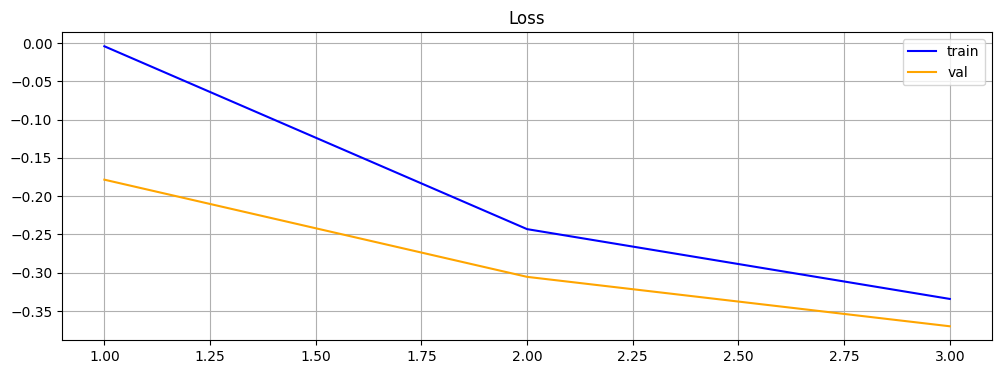

1069it [06:25,  2.77it/s]


KeyboardInterrupt: 

In [36]:
train_loop(vae, optimizer, train_loader, val_loader, 5, metrics)

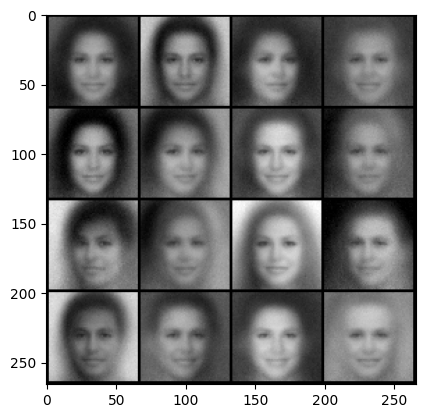

In [37]:
images, _ = list(islice(val_loader, 1))[0]
mu_gen, _, _, _ = vae(images.to(device))
mu_gen = torch.reshape(mu_gen,(-1,1,64,64))

reconstruction = mu_gen[:16].detach().cpu().clamp(0, 1)

plt.imshow(make_grid(reconstruction, nrow=4).permute(1, 2, 0))

And finally sample from VAE.

In [ ]:
# TODO
# Sample some images from the learned distribution
# 1) Sample z ~ N(0,1)
# 2) Sample from N(decoder_mu(z), decoder_sigma(z))

In [38]:
z = torch.randn(16,dimZ).to(device)

In [39]:
reconstruction, sigma = vae.decode(z)
reconstruction = torch.reshape(reconstruction,(-1,1,64,64))

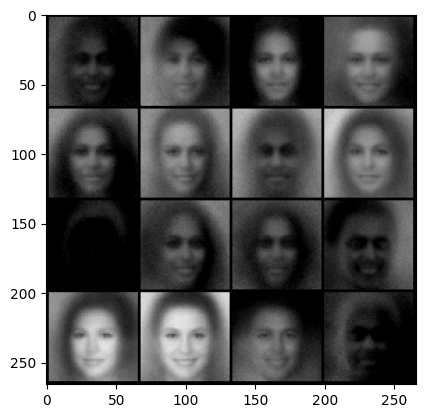

In [40]:
plt.imshow(make_grid(reconstruction.detach().cpu().clamp(0, 1), nrow=4).permute(1, 2, 0))

Even if in practice you do not see the much difference between AE and VAE, or VAE is even worse, the little bayesian inside you should be jumping for joy right now.

In VAE you can truly sample from image distribution $p(x)$, while in AE there is no easy and correct way to do it.

# If you made it here - Congrats! (and here's an optional bonus task)

If you managed to tune your autoencoders to converge and learn something about the world, now it's time to make fun out of it. As you may have noticed, there are face attributes in dataset. We're interesting in "Smiling" column (index 31 of the attribute vector), but feel free to try others as well! Here is the first task:

1) Extract the "Smilling" attribute and create a two sets of images: 10 smiling faces and 10 non-smiling ones.

2) Compute latent representations for each image in "smiling" set and average those latent vectors. Do the same for "non-smiling" set. You have found **"vector representation"** of the "smile" and "no smile" attribute.

3) Compute the difference: "smile" vector minus "non-smile" vector.

3) Now check if **"feature arithmetics"** works. Sample a face without smile, encode it and add the diff from p. 3. Check if it works with both AE and VAE.

In [41]:
ind_pos = []
ind_neg = []

In [42]:
for i in tqdm(range(len(validation_dataset))):
    if validation_dataset[i][1][31].item()==1:
        ind_pos.append(i)
    else:
        ind_neg.append(i)

100%|██████████| 19867/19867 [00:24<00:00, 815.14it/s]


In [43]:
def get_avg_encode(model,validation_dataset,inds):
    arr_mu = []
    for ind in inds:
        img = validation_dataset[ind][0]
        # mu, sigma = model.encode(img.to(device).view(-1, 64**2))
        # print(img.shape)
        # mu, sigma = model.encoder(img.to(device).view(-1, 64**2))
        mu, sigma = model.encoder(img.to(device).reshape(-1,1,64,64))
        # mu_gen, _, _, _ = vae(img.to(device))
        # mu_gen = torch.reshape(mu_gen,(-1,1,64,64))
        arr_mu.append(mu)

    # return torch.reshape(torch.cat(arr_mu,dim=0).mean(dim=0),(1,dimZ))
    return torch.reshape(torch.cat(arr_mu,dim=0).mean(dim=0),(1,latent_dim))


In [44]:
def generete(model, mu, sigma):

    z = model.gaussian_sampler(mu, sigma,len(mu))
    reconstruction_new, sigma = model.decoder(z)
    reconstruction_new = torch.reshape(reconstruction_new,(-1,1,64,64))
    return reconstruction_new

In [45]:
def add_smile(model,validation_dataset,ind,smile_vector,add_smile=True):
    img = validation_dataset[ind][0]
    # mu_changed, sigma = model.encode(img.to(device).view(-1, 64**2))
    # mu_changed, sigma = model.encoder(img.to(device).view(-1, 64**2))
    mu_changed, sigma = model.encoder(img.to(device).reshape(-1,1,64,64))

    if add_smile:
        mu_changed = mu_changed + smile_vector

    reconstruction_new = generete(model,mu_changed,sigma)
    return reconstruction_new

# Lets improve the core model architecture

In [46]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, final_relu=True):
        super().__init__()
        self.final_relu = final_relu

        self.conv1 = nn.Conv2d(in_channels=in_channels,
                              out_channels=out_channels,
                              kernel_size=(kernel_size, kernel_size), stride=1,
                               padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(in_channels=out_channels,
                              out_channels=out_channels,
                              kernel_size=(kernel_size, kernel_size), stride=(stride, stride),
                               padding=kernel_size//2)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu2 = nn.ReLU()

        self.conv1_1 = nn.Conv2d(in_channels=in_channels,
                              out_channels=out_channels,
                              kernel_size=(1, 1),stride=stride)

    def forward(self, x):

        residual = self.bn1(x)
        residual = self.conv1(residual)
        residual = self.relu1(residual)

        residual = self.bn2(residual)
        residual = self.conv2(residual)

        result = self.conv1_1(x) + residual

        if self.final_relu:
            result = self.relu2(result)

        return result

In [47]:
class ResNetTransposeBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, final_relu=True):
        super().__init__()
        self.final_relu = final_relu

        self.bn1 =  nn.BatchNorm2d(in_channels)
        self.bn2 =  nn.BatchNorm2d(in_channels)
        self.bn3 =  nn.BatchNorm2d(out_channels)

        self.upconv1 = nn.ConvTranspose2d(
            in_channels=in_channels, out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=(kernel_size-stride)//2,
        )

        self.upconv2 = nn.ConvTranspose2d(
            in_channels=in_channels, out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=(kernel_size-stride)//2,
            # output_padding=stride
        )

        self.conv = nn.Conv2d(in_channels=out_channels,
                              out_channels=out_channels,
                              kernel_size=kernel_size-1, stride=1,
                               padding=(kernel_size-2)//2
                             )

        self.relu1 = nn.ReLU()

    def forward(self, x):
        inp_change = self.upconv1(self.bn1(x))
        # print(inp_change.shape,'inp_change.shape')
        resid = self.upconv2(self.bn2(x))
        # print(resid.shape,'resid.shape')
        resid = self.bn3(resid)
        result = self.conv(resid) + inp_change
        # print(result.shape,'result.shape')

        if self.final_relu:
            result = self.relu1(result)

        return result

In [48]:
class ConvResNetEncoder(nn.Module):
    def __init__(self, input_shape, n_latent):
        super().__init__()
        self.input_shape = input_shape
        self.n_latent = n_latent

        self.channel_out = 128
        # print(self.channel_out*(input_shape[1]*input_shape[2])//16)
        self.stride1 = 1
        self.res_block1 = ResNetBlock(input_shape[0], 32 , 9, self.stride1)

        self.stride2 = 2
        self.res_block2 = ResNetBlock(32, 64, 7, self.stride2)

        self.stride3 = 2
        self.res_block3 = ResNetBlock(64, 128, 5 ,self.stride3)


        self.mu = nn.Linear(self.channel_out*(input_shape[1]*input_shape[2])//(self.stride1**2*self.stride2**2*self.stride3**2), n_latent)
        # print(self.channel_out*(input_shape[1]*input_shape[2])//(self.stride1**2*self.stride2**2))
        self.log_std = nn.Linear(self.channel_out*(input_shape[1]*input_shape[2])//(self.stride1**2*self.stride2**2*self.stride3**2), n_latent)

    def forward(self, x):

        res = self.res_block1(x)
        # print(res.shape)
        res = self.res_block2(res)
        res = self.res_block3(res)
        # print(res.shape)
        res = res.flatten(start_dim=1,end_dim=-1)

        mu = self.mu(res)
        log_std = self.log_std(res)
        return mu, log_std


class ConvResNetDecoder(nn.Module):
    def __init__(self, n_latent, output_shape):
        super().__init__()
        self.n_latent = n_latent
        self.output_shape = output_shape

        self.shape1 = output_shape[1]//4
        self.channel_in = 64
        self.unti_flatten = nn.Linear(n_latent, self.channel_in*(output_shape[1]*output_shape[2])//16)
        self.transpose1 = ResNetTransposeBlock(in_channels=self.channel_in, out_channels=32, kernel_size=6, stride=2)
        self.transpose2 = ResNetTransposeBlock(in_channels=32, out_channels=64, kernel_size=6, stride=2)
        self.transpose3 = ResNetTransposeBlock(in_channels=64, out_channels=64, kernel_size=4, stride=2)
        self.transpose4 = ResNetTransposeBlock(in_channels=64, out_channels=self.output_shape[0], kernel_size=4, stride=2)

        self.res_block = ResNetBlock(self.output_shape[0], self.output_shape[0] , 7, 2)

        self.mu = nn.Linear(output_shape[0]*(output_shape[1]*output_shape[2])*4,output_shape[0]*(output_shape[1]*output_shape[2]))

        self.log_sig = nn.Linear(output_shape[0]*(output_shape[1]*output_shape[2])*4,output_shape[0]*(output_shape[1]*output_shape[2]))

    def forward(self, z):
        res = self.unti_flatten(z).reshape((z.shape[0],self.channel_in,self.shape1,self.shape1))
        out = self.transpose1(res)
        # print(out.shape)
        out = self.transpose2(out)
        # print(out.shape)
        out = self.transpose3(out)

        out = self.transpose4(out)

        out = self.res_block(out)
        # print(out.shape)


        out_mu =  self.mu(out.reshape(-1,1*128*128)).reshape(-1,1,64,64)
        out_sigma =  self.log_sig(out.reshape(-1,1*128*128)).reshape(-1,1,64,64)

        return out_mu, out_sigma


In [49]:
class ConvResNetVAE(nn.Module):
    def __init__(self, input_shape: tuple, n_latent: int) -> None:
        super(ConvResNetVAE,self).__init__()
        assert len(input_shape) == 3

        self.input_shape = input_shape
        self.n_latent = n_latent

        self.encoder = ConvResNetEncoder(self.input_shape, n_latent=self.n_latent)
        self.decoder = ConvResNetDecoder(self.n_latent, self.input_shape)

    def prior(self, n: int) -> torch.Tensor:
        z = torch.normal(0, 1, size=(n, self.n_latent))
        z = z.to(device)
        return z

    def gaussian_sampler(self, mu, logsigma, n ):
        noise = self.prior(n)
        return (noise * logsigma.exp() + mu).to(device)


    def forward(self, x: torch.Tensor,flatten=True) -> tuple:

        mu_z, log_std_z = self.encoder(x)
        # self.encoder(x)
        z = self.gaussian_sampler(mu_z, log_std_z,len(x))
        x_recon, sigma_recon  = self.decoder(z)
        # torch.sigmoid(self.decoder(z)).view(-1, 3,32,32)
        # self.decoder(z)
        # print('x_recon',x_recon.shape)
        # print('sigma_recon',sigma_recon.shape)
        # print('mu_z',mu_z.shape)
        if flatten:
            return x_recon.reshape(-1,64**2), sigma_recon.reshape(-1,64**2), mu_z, log_std_z
        else:
            return x_recon, sigma_recon, mu_z, log_std_z
    # def sample(self, n: int) -> np.ndarray:
    #     with torch.no_grad():
    #         # ====
    #         # your code
    #         # 1) generate prior samples
    #         # 2) apply decoder

    #         # ====
    #         z = self.prior(n)
    #         x_recon = self.decoder(z)
    #         samples = torch.clamp(x_recon, -1, 1)
    #     return samples.cpu().numpy() * 0.5 + 0.5

In [50]:
latent_dim = 768
vae_new = ConvResNetVAE((1, 64, 64), latent_dim).to(device)

In [51]:
optimizer = optim.Adam(vae_new.parameters(),lr=1e-4)

In [52]:
metrics = {'train_loss': [], 'val_loss': [],'val_accuracy':[]}

In [ ]:
train_loop(vae_new, optimizer, train_loader, val_loader, 5, metrics)

13it [18:01, 80.46s/it]

In [ ]:
optimizer = optim.Adam(vae_new.parameters(),lr=5e-5)

In [ ]:
train_loop(vae_new, optimizer, train_loader, val_loader, 10, metrics)

In [ ]:
plt.imshow(make_grid(images[0:16], nrow=4).permute(1, 2, 0))

In [ ]:
images, _ = list(islice(val_loader, 1))[0]
mu_gen, _, _, _ = vae_new(images.to(device))
mu_gen = torch.reshape(mu_gen,(-1,1,64,64))

reconstruction = mu_gen[:16].detach().cpu().clamp(0, 1)

plt.imshow(make_grid(reconstruction, nrow=4).permute(1, 2, 0))

In [ ]:
z = torch.randn(36,latent_dim).to(device)

In [ ]:
reconstruction, sigma = vae_new.decoder(z)
reconstruction = torch.reshape(reconstruction,(-1,1,64,64))

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(make_grid(reconstruction.detach().cpu().clamp(0, 1), nrow=6).permute(1, 2, 0))

In [ ]:
reconstruction_pos = get_avg_encode(vae_new,validation_dataset,ind_pos[:1000])
reconstruction_neg = get_avg_encode(vae_new,validation_dataset,ind_neg[:1000])
smile_vector = reconstruction_pos-reconstruction_neg

In [ ]:
smile_vector.shape

In [ ]:
k=ind_neg[47]

In [ ]:
plt.imshow(make_grid(validation_dataset[k][0].detach().cpu().clamp(0, 1)).permute(1, 2, 0))

In [ ]:
reconstruction_new = add_smile(vae_new,validation_dataset,k,smile_vector,False)

In [ ]:
plt.imshow(make_grid(reconstruction_new.detach().cpu().clamp(0, 1)).permute(1, 2, 0))

In [ ]:
reconstruction_new = add_smile(vae_new,validation_dataset,k,smile_vector,True)

In [ ]:
plt.imshow(make_grid(reconstruction_new.detach().cpu().clamp(0, 1)).permute(1, 2, 0))

For accurate benchmarking, we'll train an architecturally identical AE by substituting the VAE loss with the base reconstruction loss and retraining

In [ ]:
def loss_vae(x, mu_gen, logsigma_gen, mu_z, logsigma_z):
    return compute_loss(mu_gen,x)

In [ ]:
latent_dim = 768
ae_new = ConvResNetVAE((1, 64, 64), latent_dim).to(device)

In [ ]:
optimizer = optim.Adam(ae_new.parameters(),lr=1e-4)

In [ ]:
metrics = {'train_loss': [], 'val_loss': [],'val_accuracy':[]}

In [ ]:
train_loop(ae_new, optimizer, train_loader, val_loader, 5, metrics)

In [ ]:
images, _ = list(islice(val_loader, 1))[0]
mu_gen, _, _, _ = ae_new(images.to(device))
mu_gen = torch.reshape(mu_gen,(-1,1,64,64))

reconstruction = mu_gen[:16].detach().cpu().clamp(0, 1)

plt.imshow(make_grid(reconstruction, nrow=4).permute(1, 2, 0))

In [ ]:
z = torch.randn(36,latent_dim).to(device)

In [ ]:
reconstruction, sigma = ae_new.decoder(z)
reconstruction = torch.reshape(reconstruction,(-1,1,64,64))

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(make_grid(reconstruction.detach().cpu().clamp(0, 1), nrow=6).permute(1, 2, 0))

In [ ]:
reconstruction_pos = get_avg_encode(ae_new,validation_dataset,ind_pos[:1000])
reconstruction_neg = get_avg_encode(ae_new,validation_dataset,ind_neg[:1000])
smile_vector = reconstruction_pos-reconstruction_neg

In [ ]:
k=ind_neg[47]

In [ ]:
reconstruction_new = add_smile(ae_new,validation_dataset,k,smile_vector,False)

In [ ]:
plt.imshow(make_grid(reconstruction_new.detach().cpu().clamp(0, 1)).permute(1, 2, 0))

In [ ]:
reconstruction_new = add_smile(ae_new,validation_dataset,k,smile_vector,True)

In [ ]:
plt.imshow(make_grid(reconstruction_new.detach().cpu().clamp(0, 1)).permute(1, 2, 0))

# Results

The experiments demonstrate that "feature arithmetic" in latent space is not exclusive to VAEs; it also functions in a standard Autoencoder of a comparable architecture, successfully adding attributes like a smile to a reconstructed image.

However, the fundamental advantage of the VAE architecture becomes clear when evaluating their generative power. When sampling from the latent space, the simple AE produces blurry and unrecognizable outputs that only faintly resemble the contours of faces. The more complex VAE, leveraging its probabilistic framework and regularization, generates convincing, realistic faces, highlighting its superior ability to model the true underlying data manifold.